# Figure 2 - Analysis of toy metabolic network

This notebook performs analysis of simulation results of the toy metabolic network to generate Figure 2 in the main text.

In [1]:
import os
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from evcm.analysis import *

First, we will load the simulation data

In [2]:
root_3211 = r'./toynet_simulation_data/'
sims_3211 = sorted(os.listdir(root_3211))

for s in reversed(sims_3211): #There are other files in the simulation data folder that we don't want to try to load
    if '3211' in s:
        sims_3211.remove(s)

__DEBUG__=False #If True, only load a the initial periods of the simulation, but does nothing here as there is only one period
biomass_3211,ubounds_3211,lbounds_3211,flux_3211 = load_sim_results(root_3211,
                                           ['biomass','ubounds','lbounds','flux'],[3,4,4,4],
                                           sims_3211,dtypes=[{},{'Gene':str},{'Gene':str},{'Reaction':str}],debug=__DEBUG__)

Then, we load the toy network matrices

In [3]:
mats_3211 = load_mats(root_3211,sims_3211)

Next, we load some already performed analysis. `SPu_3211` contains values of $\lambda$ throughout the simulation, and `outcomeSP_3211` contains the selective pressure on the simulation outcome

In [4]:
filename_root_3211 = root_3211+'toynet_3211'+'__'+'2025_11_22'+'__'

SPu_3211 = pl.read_csv(filename_root_3211+'SPu.csv') #Data generated with evcm.analysis.calculate_shadow_prices_from_sim()
outcomeSP_3211 = pl.read_csv(filename_root_3211+'outcomeSP.csv') #Data generated with evcm.analysis.SP_on_simoutcome()

### Details for plotting

In [5]:
ubounds_3211=ubounds_3211.with_columns(pl.col('Gene').replace({'0':'1','1':'2','2':'3','3':'4'}))
lbounds_3211=lbounds_3211.with_columns(pl.col('Gene').replace({'0':'1','1':'2','2':'3','3':'4'}))
flux_3211=flux_3211.with_columns(pl.col('Reaction').replace({'0':'1','1':'2','2':'3','3':'4'}))

simulation_palette=['#37B34A','#B2D732','#66B032','#347B98','#092834']
simulation_hue_order = ['toynet_20251029__001259__',
 'toynet_20251029__002450__',
 'toynet_20251029__015557__',
 'toynet_20251029__015826__',
 'toynet_20251029__020157__']

reaction_palette = list(reversed(["#EA202C",
"#448D76",
"#FB8604",
"#4424D6"]))
reaction_hue_order = list(reversed(["4","3","2","1"]))

ubounds_palette = list(reversed(["#EA202C",
"#448D76",
"#FB8604",
"#4424D6"]))
ubounds_hue_order = list(reversed(["4",
"3",
"2",
"1"]))

hlines_for_3211 = np.array([3,2,1,1])
hlines_for_3211 = hlines_for_3211/np.linalg.norm(hlines_for_3211)

cm_scale=3/hlines_for_3211.max()
hlines_for_3211 = hlines_for_3211*cm_scale

_cm_ = 1/2.54
_onecolumn_ = 8.7*_cm_
_sidelegend_ = 11.4*_cm_
_widefig_ = 17.8*_cm_


# Calculations for figure 2

We downsample a lot of the data for visual clarity

In [6]:
__TIME_DOWNSAMPLE__ = 1000
__MARKER_DOWNSAMPLE__ = __TIME_DOWNSAMPLE__*50
__SP_DOWNSAMPLE__ = 10 #Already downsampled by 10 when calculation was performed

We selected one simulation as the key simulation for Figure 2. You can select another to see how Figure 2 changes.

In [7]:
key_sim_3211 = simulation_hue_order[0]

Select the biomass (growth rate) of the key simulation

In [8]:
biomass_key_ds_3211 = biomass_3211.filter(pl.col('Sim').eq(key_sim_3211)).select(pl.all().gather_every(__TIME_DOWNSAMPLE__).over('Sim',mapping_strategy='explode'))



Select the fluxes of the key simulation

In [9]:
flux_key_ds_3211 = flux_3211.filter(pl.col('Sim').eq(key_sim_3211)).select(pl.all().gather_every(__TIME_DOWNSAMPLE__).over(['Sim','Reaction'],mapping_strategy='explode'))
flux_key_ds_3211_formarkers1 = flux_3211.filter(pl.col('Sim').eq(key_sim_3211)).select(pl.all().gather_every(__MARKER_DOWNSAMPLE__).over(['Sim','Reaction'],mapping_strategy='explode'))
flux_key_ds_3211_formarkers2 = flux_3211.filter(pl.col('Sim').eq(key_sim_3211)).select(pl.all().gather_every(__MARKER_DOWNSAMPLE__,offset=__MARKER_DOWNSAMPLE__//2).over(['Sim','Reaction'],mapping_strategy='explode'))



Calculate the normalized, rolling average change in flux throughout the simulation. Also, downsample the data to make markers

In [10]:
flux_key_normchange_3211 = normalize_by_norm(
                            rolling_average_difference(flux_3211.filter(pl.col('Sim').eq(key_sim_3211)),'Flux','Reaction','Sim',window=5000),
                            'Time','Flux','Sim')
flux_key_normchange_ds_3211 = flux_key_normchange_3211.with_columns(pl.col('Flux')*cm_scale).\
                            select(pl.all().gather_every(__TIME_DOWNSAMPLE__).over(['Sim','Reaction'],mapping_strategy='explode'))

flux_key_normchange_ds_3211_formarkers1 = flux_key_normchange_3211.with_columns(pl.col('Flux')*cm_scale).\
                                            select(pl.all().gather_every(__MARKER_DOWNSAMPLE__).over(['Sim','Reaction'],mapping_strategy='explode'))

flux_key_normchange_ds_3211_formarkers2 = flux_key_normchange_3211.with_columns(pl.col('Flux')*cm_scale).\
                                            select(pl.all().gather_every(__MARKER_DOWNSAMPLE__,offset=__MARKER_DOWNSAMPLE__//2).over(['Sim','Reaction'],mapping_strategy='explode'))


Calculate the normalized simulation outcome (final fluxes) of the simulation for all replicates

In [11]:
normalized_final_flux_3211 = flux_3211.filter((pl.col('Time').eq(pl.col('Time').max())).over('Sim')).\
    with_columns((pl.col('Flux')/(((pl.col('Flux')**2).sum()).sqrt())*cm_scale).over('Sim'))

Select the selective pressure on individual genes (components of $\lambda$) and the selective pressure on the simulation outcome. We only show a small portion of the simulation in Figure 2.

In [12]:
SPu_key_3211 = SPu_3211.filter(pl.col('Sim').eq(key_sim_3211))
SPu_key_3211 = SPu_key_3211.with_columns(pl.col('Constraint').replace({'0___u':'1','1___u':'2','2___u':'3','3___u':'4'}))
SPu_key_3211 = SPu_key_3211.select(pl.all().gather_every(__SP_DOWNSAMPLE__).over('Sim','Constraint',mapping_strategy='explode'))

outcomeSP_key_3211 = outcomeSP_3211.filter(pl.col('Sim').eq(key_sim_3211))
outcomeSP_key_3211 = outcomeSP_key_3211.select(pl.all().gather_every(__SP_DOWNSAMPLE__).over('Sim',mapping_strategy='explode'))

SP_range_3211 = (1.05e6,1.1e6)

SPu_key_zoom_3211 = SPu_key_3211.filter(pl.col('Time').ge(SP_range_3211[0]),pl.col('Time').le(SP_range_3211[1]))
outcomeSP_key_zoom_3211 = outcomeSP_key_3211.filter(pl.col('Time').ge(SP_range_3211[0]),pl.col('Time').le(SP_range_3211[1]))

# Figure 2

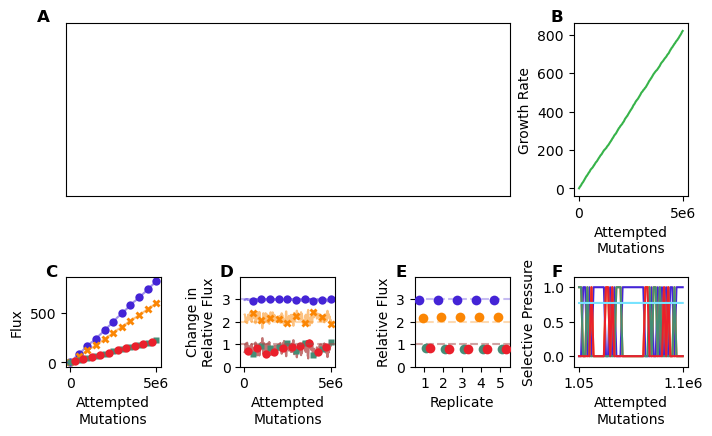

In [13]:
M = """
    AAAB
    CDEF
    """
_width_=_widefig_
_height_=4.25
_labelpad_ = 4
fig,axd = plt.subplot_mosaic(M,figsize=(_width_,_height_),layout='constrained',
                             height_ratios=[2.8,_height_-2.8],width_ratios=[5/3,5/3,5/3,_widefig_-5])

# A ==========================================================================
_a_ = 'A'
axd[_a_].set_xticks([])
axd[_a_].set_yticks([])

# B ==========================================================================
_a_ = 'B'

sns.lineplot(biomass_key_ds_3211,x='Time',y='Biomass',hue='Sim',
             palette=simulation_palette,hue_order=simulation_hue_order,
             legend=False,
             ax=axd[_a_])
axd[_a_].set_ylabel('Growth Rate')
axd[_a_].set_xlabel('Attempted\nMutations',labelpad=_labelpad_)
axd[_a_].set_xticks([0,5e6],['0','5e6']) # DOUBLE CHECK IF MOVING

# C ==========================================================================
_a_ = 'C'
sns.lineplot(flux_key_ds_3211,x='Time',y='Flux',hue='Reaction',
             palette=ubounds_palette,hue_order=ubounds_hue_order,
             legend=False,alpha=0.5,
             ax=axd[_a_])
sns.lineplot(flux_key_ds_3211_formarkers1.filter(pl.col('Reaction').is_in(['1','2','3'])),
             x='Time',y='Flux',hue='Reaction',style='Reaction',markers=True,dashes=False,
             palette=ubounds_palette,hue_order=ubounds_hue_order,linewidth=0,markeredgecolor='none',
             legend=False,
             ax=axd[_a_])
sns.lineplot(flux_key_ds_3211_formarkers2.filter(pl.col('Reaction').is_in(['4'])),
             x='Time',y='Flux',hue='Reaction',style='Reaction',markers=True,dashes=False,
             palette=ubounds_palette,hue_order=ubounds_hue_order,linewidth=0,markeredgecolor='none',
             legend=False,
             ax=axd[_a_])
             

axd[_a_].set_ylabel('Flux')
axd[_a_].set_xlabel('Attempted\nMutations',labelpad=_labelpad_)
axd[_a_].set_xticks([0,5e6],['0','5e6']) # DOUBLE CHECK IF MOVING


# D ==========================================================================
_a_ = 'D'
sns.lineplot(flux_key_normchange_ds_3211,x='Time',y='Flux',hue='Reaction',
             palette=ubounds_palette,hue_order=ubounds_hue_order,
             legend=False,alpha=0.5,
             ax=axd[_a_])

sns.lineplot(flux_key_normchange_ds_3211_formarkers1.filter(pl.col('Reaction').is_in(['1','2','3'])),
             x='Time',y='Flux',hue='Reaction',style='Reaction',markers=True,dashes=False,
             palette=ubounds_palette,hue_order=ubounds_hue_order,linewidth=0,markeredgecolor='none',
             legend=False,
             ax=axd[_a_])
sns.lineplot(flux_key_normchange_ds_3211_formarkers2.filter(pl.col('Reaction').is_in(['4'])),
             x='Time',y='Flux',hue='Reaction',style='Reaction',markers=True,dashes=False,
             palette=ubounds_palette,hue_order=ubounds_hue_order,linewidth=0,markeredgecolor='none',
             legend=False,
             ax=axd[_a_])
             

for (i_v,v) in enumerate(hlines_for_3211):
    axd[_a_].axhline(v,color=ubounds_palette[i_v],linestyle='--',alpha=0.3)
             

axd[_a_].set_ylabel('Change in\nRelative Flux')
axd[_a_].set_xlabel('Attempted\nMutations',labelpad=_labelpad_)
axd[_a_].set_ylim([0,4])
axd[_a_].set_yticks([0,1,2,3])

axd[_a_].set_xticks([0,5e6],['0','5e6']) # DOUBLE CHECK IF MOVING


# E ==========================================================================
_a_ = 'E'
sns.stripplot(normalized_final_flux_3211,x='Sim',y='Flux',hue='Reaction',
              palette=ubounds_palette,hue_order=ubounds_hue_order,
              size=7,dodge=True,
              order=simulation_hue_order,
              legend=False,
              ax=axd[_a_])

for (i_v,v) in enumerate(hlines_for_3211):
    axd[_a_].axhline(v,color=ubounds_palette[i_v],linestyle='--',alpha=0.3)

axd[_a_].set_xticks(axd['E'].get_xticks(),np.arange(1,6))
axd[_a_].set_yticks([0,1,2,3])
axd[_a_].set_xlabel('Replicate')
axd[_a_].set_ylabel('Relative Flux')
axd[_a_].set_ylim([0,4])


# F ==========================================================================
_a_ = 'F'
sns.lineplot(SPu_key_zoom_3211,x='Time',y='Lambda',hue='Constraint',
             palette=ubounds_palette,hue_order=ubounds_hue_order,
             legend=False,
             ax=axd[_a_])
sns.lineplot(outcomeSP_key_zoom_3211,x='Time',y='Selective Pressure',hue='Sim',
             palette=['#76e3ff'],
             legend=False,
             ax=axd[_a_])


axd[_a_].set_xlabel('Attempted\nMutations',labelpad=_labelpad_)
axd[_a_].set_ylabel('Selective Pressure')
axd[_a_].set_ylim([-0.15,1.15])

axd[_a_].set_xticks([1.05e6,1.1e6],['1.05','1.1e6']) # DOUBLE CHECK IF MOVING


#   ==========================================================================

for label, ax in axd.items():
    if label!='A':
        ax.set_title(label, x=-0.15,y=1.01,size='large',weight='bold',pad=0)
    else:
        ax.set_title(label, x=-0.15/3,y=1.01,size='large',weight='bold',pad=0)





fig.show()